# Task 1: Iris Flower Classification

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
sns.set_style("whitegrid")

1. Load the Iris dataset

In [5]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Shape:", df.shape)
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


2. EDA: shape, dtypes, nulls, descriptive statistics

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [7]:
print("Null values:\n", df.isnull().sum())
df.describe()

Null values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


3. Visualisations: pairplot and box plots by species

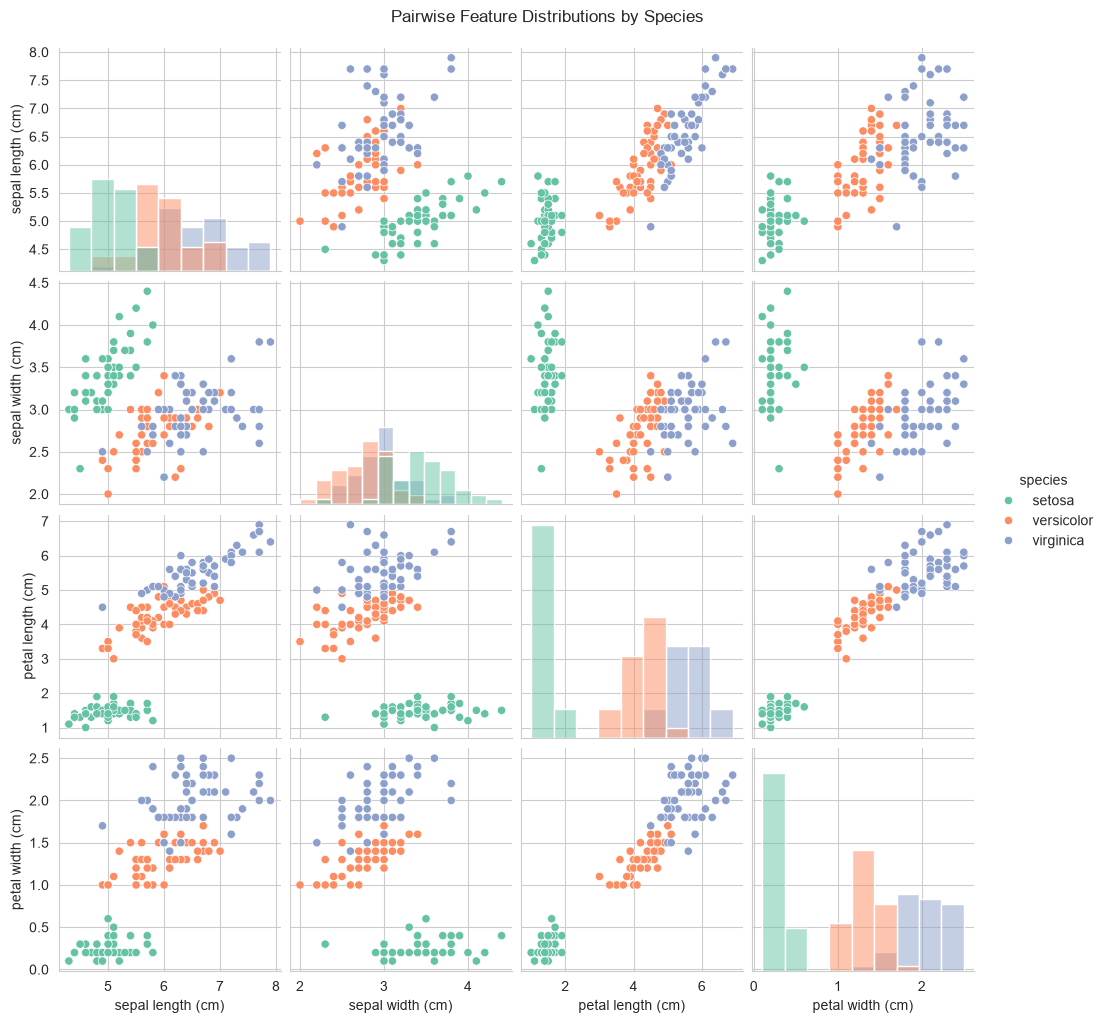

In [8]:
sns.pairplot(df, hue="species", diag_kind="hist", palette="Set2")
plt.suptitle("Pairwise Feature Distributions by Species", y=1.02)
plt.show()

C:\Users\sudar\AppData\Local\Temp\ipykernel_5868\3172947603.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
C:\Users\sudar\AppData\Local\Temp\ipykernel_5868\3172947603.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
C:\Users\sudar\AppData\Local\Temp\ipykernel_5868\3172947603.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
C:\Users\sudar\AppData\Local\Temp\ipykernel

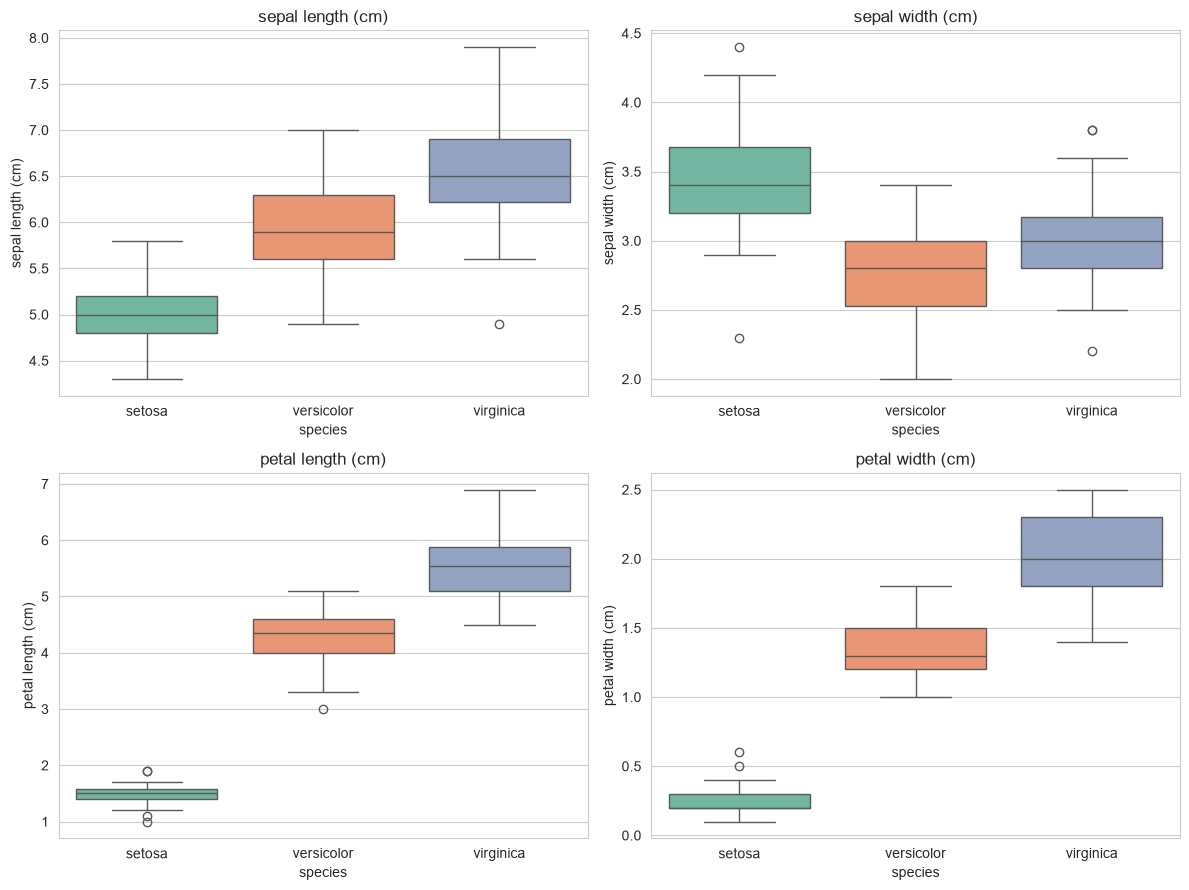

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feature in zip(axes.flat, iris.feature_names):
    sns.boxplot(data=df, x="species", y=feature, ax=ax, palette="Set2")
    ax.set_title(feature)
plt.tight_layout()
plt.show()

4. Train/test split

In [10]:
X = df[iris.feature_names]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 120 | Test size: 30


5. Train multiple classifiers

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

6. Evaluate each model

In [12]:
accuracy_scores = {}
for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    accuracy_scores[name] = acc
    print(f"--- {name} ---")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, preds))

--- Logistic Regression ---
Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

--- K-Nearest Neighbours ---
Accuracy: 1.0
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

--- Decision Tree ---
Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  

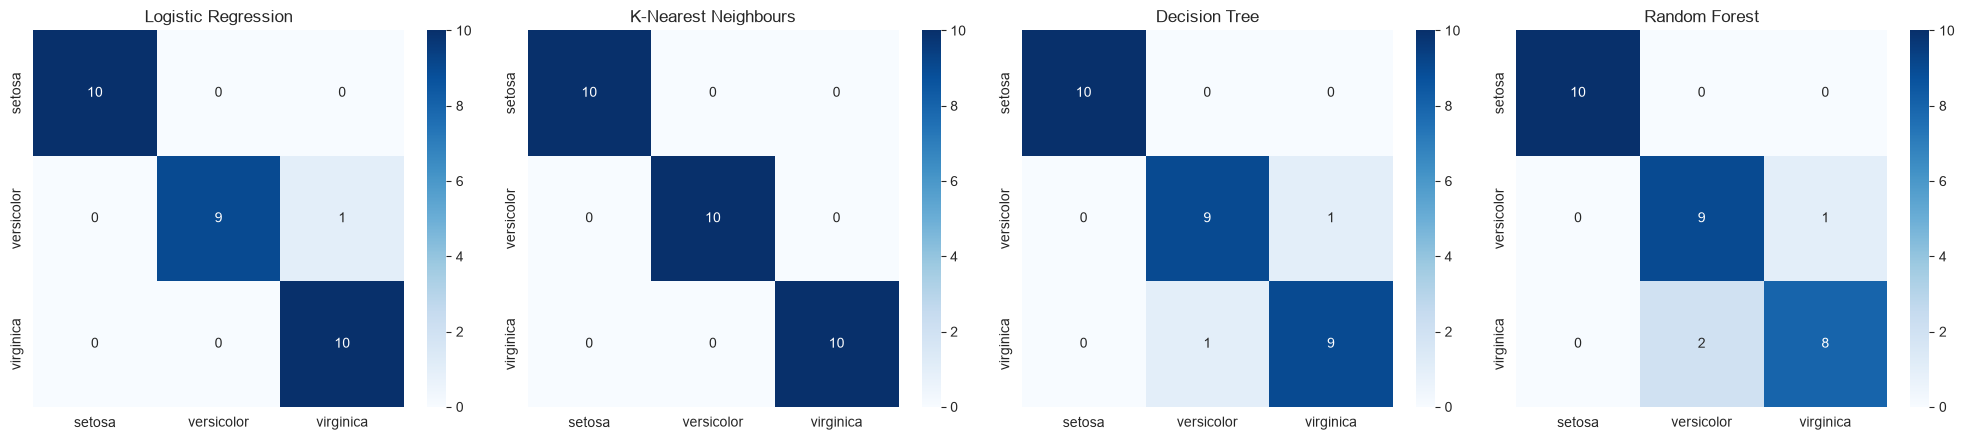

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
labels = iris.target_names
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

7. Best-performing model

In [14]:
accuracy_df = pd.DataFrame(list(accuracy_scores.items()), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
accuracy_df

,Model,Accuracy
1,K-Nearest Neighbours,1.000000
0,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.900000
